## Выполнение домашней работы 4. Линейная регрессия

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Загрузка данных...")
df = pd.read_csv('sample_data/ToyotaCorolla.csv')

Загрузка данных...


Краткий обзор данных:

In [42]:
df.size

56004

In [43]:
 df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [44]:
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [45]:
df.groupby("Color")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Color,,,,,,,,
Beige,3.0,8933.333333,880.814017,8400.0,8425.0,8450.0,9200.0,9950.0
Black,191.0,11053.848168,3707.250575,4400.0,8450.0,9950.0,12450.0,22500.0
Blue,283.0,10836.438163,3725.648618,5600.0,8075.0,9750.0,12200.0,23750.0
Green,220.0,9836.109091,2163.661571,5150.0,8362.5,9450.0,10950.0,21950.0
Grey,301.0,11927.342193,4687.176006,5900.0,8750.0,10500.0,13950.0,32500.0
Red,278.0,9962.697842,2428.567181,5740.0,8500.0,9500.0,10950.0,21500.0
Silver,122.0,11070.680328,4006.383956,4750.0,8562.5,9950.0,12362.5,23950.0
Violet,4.0,9575.000000,1701.714821,7950.0,8700.0,9200.0,10075.0,11950.0
White,31.0,8207.903226,1966.545946,4350.0,6950.0,8250.0,9675.0,12950.0


In [46]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


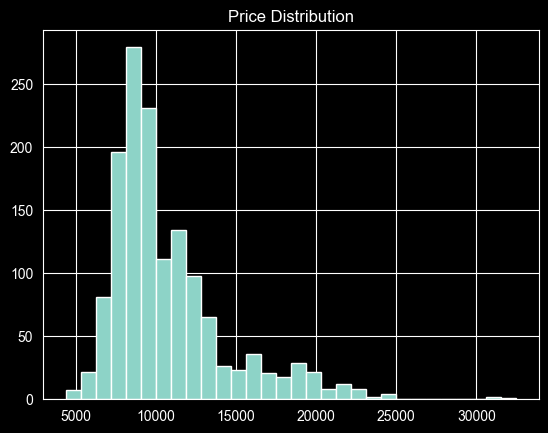

In [47]:
plt.hist(df["Price"], bins=30)
plt.title("Price Distribution")
plt.show()

<Axes: xlabel='Fuel_Type', ylabel='Price'>

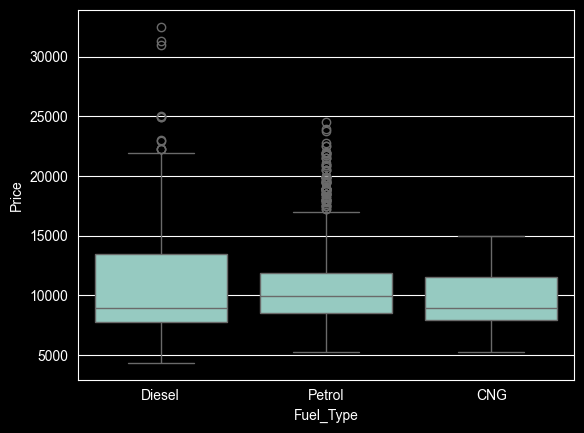

In [48]:
sns.boxplot(x="Fuel_Type", y="Price", data=df)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Blue'),
  Text(1, 0, 'Silver'),
  Text(2, 0, 'Black'),
  Text(3, 0, 'White'),
  Text(4, 0, 'Grey'),
  Text(5, 0, 'Red'),
  Text(6, 0, 'Green'),
  Text(7, 0, 'Yellow'),
  Text(8, 0, 'Violet'),
  Text(9, 0, 'Beige')])

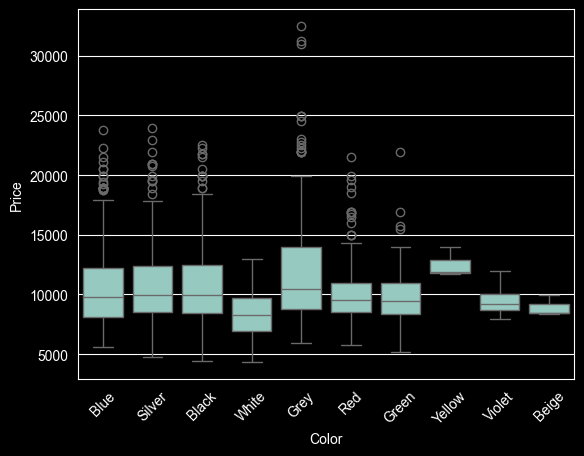

In [49]:
sns.boxplot(x="Color", y="Price", data=df)
plt.xticks(rotation=45)

Я хотел проверить насколько нужны столбцы: Fuel_Type, Color, думая что тип топлива крайне важен, а цвет машины нет.
На графиках выше, показано, что тип топлива не так важен, хотя если посмотреть на все выбросы и коробки, то тип топлива очень важен поэтому буду разделять их и оставлю столбец. Тогда как с цветом не все так однозначно, как раньше было показано по количеству машин того или иного цвета: например, желтого, что цена высокая, но машин тоже немного (3), фиолетовых(4), бежевых и белых тоже небольшое количество, то мы можем пренебречь этими данными для лучшей работы нашей модели.

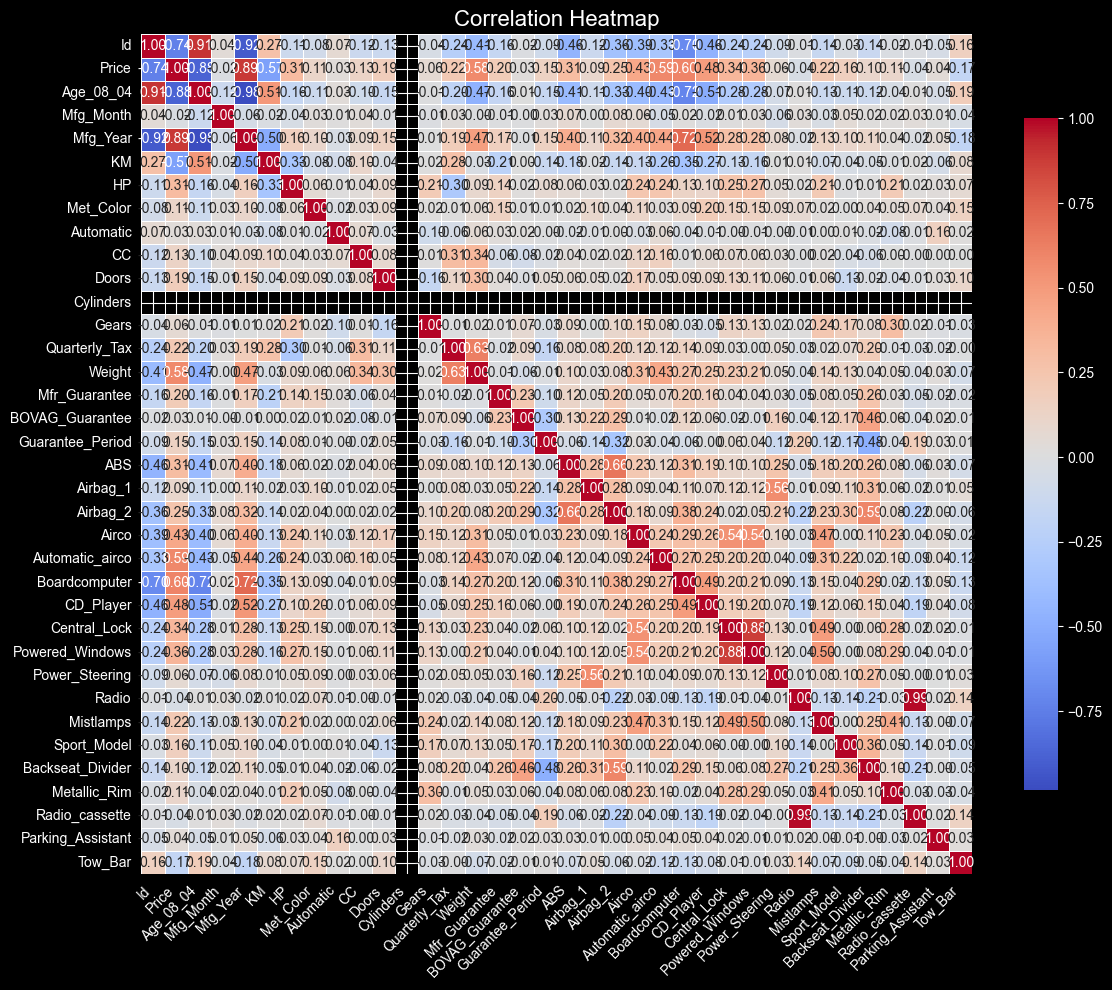

In [50]:
plt.figure(figsize=(12,10))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

По таблице кореляции видно, что цилиндры не важны из-за NaN, тогда исключим этот столбец

In [51]:
df = df.drop("Cylinders", axis=1)

In [52]:
corr["Price"].sort_values(ascending=False)

Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar             -0.172369
KM                  -0.569960
Id        

In [53]:
df = pd.get_dummies(df, columns=["Fuel_Type"])

In [54]:
df = df.drop("Model", axis=1)
df = df.drop("Color", axis=1)

## Выполнение Работа с признаками (Feature Engineering)

Я очистил данные от неиспользуемых столбцов Cylinders, также предположил о том, что Color не сильно важен, что я и доказал и убрал и этот столбец. Также разделил категориальный столбец Fuel_Type, для верного использования модели.

Также хотелось бы добавить фичу с интенсивностью использования машины: KM/Age

In [55]:
df["KM_per_year"] = df["KM"] / df["Age_08_04"]

## Разделение выборки

In [56]:
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)   # всё кроме цены
y = df["Price"]                # цена

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% на тест
    random_state=42     # фиксируем случайность
)

print(X_train.shape)
print(X_test.shape)

(1148, 38)
(288, 38)


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 1436 non-null   int64  
 1   Price              1436 non-null   int64  
 2   Age_08_04          1436 non-null   int64  
 3   Mfg_Month          1436 non-null   int64  
 4   Mfg_Year           1436 non-null   int64  
 5   KM                 1436 non-null   int64  
 6   HP                 1436 non-null   int64  
 7   Met_Color          1436 non-null   int64  
 8   Automatic          1436 non-null   int64  
 9   CC                 1436 non-null   int64  
 10  Doors              1436 non-null   int64  
 11  Gears              1436 non-null   int64  
 12  Quarterly_Tax      1436 non-null   int64  
 13  Weight             1436 non-null   int64  
 14  Mfr_Guarantee      1436 non-null   int64  
 15  BOVAG_Guarantee    1436 non-null   int64  
 16  Guarantee_Period   1436 non-null   

In [58]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Также сделаем масштабирование данных из-за того, что линейные модели чувстительны к масштабу.

## Обучение моделей

In [59]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time

Модели и время их обучения:

In [60]:
start = time.time()

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_time = time.time() - start

In [61]:
start = time.time()

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_time = time.time() - start

In [62]:
start = time.time()

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_time = time.time() - start

Оценка моделей, возвращающая MAE, RMSE

In [63]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    return mae, rmse

Cравнение моделей

In [64]:
print("Linear:", evaluate(lr, X_test, y_test), "time:", lr_time)
print("Ridge:", evaluate(ridge, X_test, y_test), "time:", ridge_time)
print("Lasso:", evaluate(lasso, X_test, y_test), "time:", lasso_time)

Linear: (800.7945325348778, 1189.7943807460372) time: 0.010674238204956055
Ridge: (800.5208547130219, 1187.1534834988427) time: 0.00648808479309082
Lasso: (800.7646576605043, 1189.6110136858333) time: 0.031028270721435547


Как видно из итога, что самая быстрая модель это базовая линейная регрессия и самая плохая по предсказыванию. Медленнее всего был Ridge, но самые лучшая по предсказыванию. Lasso средняя по всем параметрам. Поэтому в дальнейшем рассмотрим подбор гиперпараметров для Ridge

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid_ridge.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [67]:
print(grid_ridge.best_params_)

{'alpha': 100}


In [68]:
best_ridge = grid_ridge.best_estimator_

## Проверка теперь на test

In [69]:
y_pred = best_ridge.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Ridge (best):", mae, rmse)

Ridge (best): 817.6416921527842 1172.540891525636


## Ответы на вопросы:
1. Для оценки моделей были использованы метрики MAE и RMSE. MAE (Mean Absolute Error) показывает среднюю абсолютную ошибку предсказаний и легко интерпретируется, так как измеряется в тех же единицах, что и целевая переменная (цена автомобиля). RMSE (Root Mean Squared Error) сильнее штрафует большие ошибки, так как возводит их в квадрат. Это важно в данной задаче, поскольку крупные ошибки в предсказании цены автомобиля нежелательны.
2. Метрики рассчитывались на тестовой выборке, которая не использовалась при обучении моделей. Это позволяет объективно оценить качество модели на новых данных.
3. По итогу справиля лучше всего Ridge. Хоть и больше затрачивается времени.
4. Меня итоговые результаты вполне удовлетворили, так как цена предсказанная моделью различается всего лишь в 817, когда средняя цена машины 10730. То есть погрешность от среднего значения вне превышает и 8 процентов, а это достойный результат.
5. Моя модель не переобучилась, так как она показывает примерно похожие результаты на тесте и трейне, а не большие просадки по MAE и RMSE, то есть они не сильно отличаются.